In [8]:
%load_ext autoreload
%autoreload 2

from ml.surrogate import SurrogateInversion, train_surrogate, Surrogate
from simulation.make_dataset import make_dataset
from constants import *

import torch as t
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as patches
from typing import Optional, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 11, "figure.dpi": 140})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Fixed values for plotting
phys = PhysicsConstants()
params = SimulationParameters()
dataset = DatasetParameters(filename= "ml_fig_dataset.npz")


In [15]:
make_dataset(phys, params, dataset)
ml_params = MLParameters(data_filepath="/u/mgalexan/NPSurr/data/ml_fig_dataset.npz", save_path="/u/mgalexan/NPSurr/data/fig_model.pt")
train_hist, val_hist = train_surrogate(ml_params) 

d_val_m:   0%|          | 0/81 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [10]:
model = t.load("/u/mgalexan/NPSurr/data/surrogate_model.pt", weights_only=False)
d_vals = np.linspace(20, 80, 25) * 1e-9
tau_vals = np.linspace(6, 24, 25) * 3600
inv = SurrogateInversion(model, InversionParameters(), phys, params)



In [4]:
L_surrs = []; L_pdes = []
points = [
    (35e-9, 9 * 3600),
    (55e-9, 14 * 3600),
    (75e-9, 19 * 3600)
]
for d_val_m, tau in points: 
    phys = PhysicsConstants(d_val_m= d_val_m, tau= tau)
    obs_dataset_params = DatasetParameters(    
        d_val_m= np.array([d_val_m]),
        tau= np.array([tau]),
        save= False
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0,0]; obs_dataset["CF"] = obs_dataset["CF"][0,0]; obs_dataset["CI"] = obs_dataset["CI"][0,0]
    L_surrs.append(inv.loss_surface(obs_dataset, d_vals, tau_vals))
    L_pdes.append(inv.pde_misfit_surface(obs_dataset, d_vals, tau_vals))

d_val_m:   0%|          | 0/1 [00:00<?, ?it/s]

  4%|▍         | 1/25 [00:00<00:22,  1.08it/s]


KeyboardInterrupt: 

In [5]:
def plot_surrogate_landscape_grid(
        L_surrs: list[ np.ndarray ],
        L_pdes: list[ np.ndarray ],
        d_grid: np.ndarray,
        tau_grid: np.ndarray,
        pred_points: list[tuple[float, float]],
        true_points: Optional[list[tuple[float, float]]] = None,
        fig: Optional[plt.Figure] = None,
        axes: Optional[np.ndarray] = None,
        surr_norm: Optional[colors.Normalize] = None,
        pde_norm: Optional[colors.Normalize] = None,
    ) -> tuple[plt.Figure, np.ndarray]:

        n = len(pred_points)
        if true_points is None:
            true_points = n * [None]
        if fig is None or axes is None:
                # Use gridspec_kw to increase horizontal spacing between columns and
                # disable constrained_layout so gridspec spacing takes effect.
                fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 6.0), sharex=True, sharey=True, gridspec_kw={'wspace': 0.25, 'hspace': 0.15}, constrained_layout=False)

        if axes.ndim == 1:
            axes = axes.reshape(2, -1)

        # Convert surrogate log-loss back to raw values and clean arrays
        surr_clean_list = [np.where(np.isfinite(L) & (np.exp(L) >= 0), np.exp(L), np.nan) for L in L_surrs]
        pde_clean_list = [np.where(np.isfinite(L) & (L >= 0), L, np.nan) for L in L_pdes]

        # Compute separate normalization for surrogate and PDE rows
        surr_all = np.concatenate([arr.ravel() for arr in surr_clean_list])
        surr_finite = surr_all[np.isfinite(surr_all)]
        if surr_norm is None:
            if surr_finite.size > 0:
                surr_norm = colors.Normalize(vmin=surr_finite.min(), vmax=surr_finite.max())
            else:
                surr_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        pde_all = np.concatenate([arr.ravel() for arr in pde_clean_list])
        pde_finite = pde_all[np.isfinite(pde_all)]
        if pde_norm is None:
            if pde_finite.size > 0:
                pde_norm = colors.Normalize(vmin=pde_finite.min(), vmax=pde_finite.max())
            else:
                pde_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        x = d_grid * 1e9
        y = tau_grid / 3600.0

        # Keep track of last pcm handles (one per row) to build colorbars
        last_pcm_surr = None
        last_pcm_pde = None

        for col, (ax_surf, ax_pde, L_surf_clean, L_pde_clean, true_pt, pred_pt) in enumerate(zip(axes[0], axes[1], surr_clean_list, pde_clean_list, true_points, pred_points)):
            last_pcm_surr = ax_surf.pcolormesh(
                x,
                y,
                L_surf_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm=surr_norm,
            )
            ax_surf.contour(
                x,
                y,
                L_surf_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_surf.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1] / 3600.0,
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
            )
            ax_surf.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1] / 3600.0,
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            if true_pt:
                ax_surf.set_title(rf"$d={true_pt[0]*1e9:.0f}\ \mathrm{{nm}},\ \tau={true_pt[1]/3600.0:.0f}\ \mathrm{{h}}$" + "\nSurrogate")
            ax_surf.grid(alpha=0.25)
            ax_surf.legend(fontsize=9, loc="upper right", frameon= True)

            last_pcm_pde = ax_pde.pcolormesh(
                x,
                y,
                L_pde_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm=pde_norm,
            )
            ax_pde.contour(
                x,
                y,
                L_pde_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_pde.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1] / 3600.0,
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
                )
            ax_pde.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1] / 3600.0,
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            ax_pde.set_title("PDE")
            ax_pde.grid(alpha=0.25)
            ax_pde.legend(fontsize=9, loc="upper right", frameon= True)

        for ax in axes[1, :]:
            ax.set_xlabel(r"$d$ (nm)")
        for ax in axes[:, 0]:
            ax.set_ylabel(r"$\tau$ (h)")

        fig.suptitle("Surrogate vs PDE loss landscape per evaluated point", fontsize=16, y=1.02)

        # Create compact colorbars adjacent to the last column of each row
        if last_pcm_surr is not None:
            divider = make_axes_locatable(axes[0, -1])
            cax_surr = divider.append_axes("right", size="3%", pad=0.1)
            cbar_surr = fig.colorbar(last_pcm_surr, cax=cax_surr)
            cbar_surr.set_label(r"$\mathcal{L}_{surr}$")
        if last_pcm_pde is not None:
            divider = make_axes_locatable(axes[1, -1])
            cax_pde = divider.append_axes("right", size="3%", pad=0.1)
            cbar_pde = fig.colorbar(last_pcm_pde, cax=cax_pde)
            cbar_pde.set_label(r"$\mathcal{L}_{PDE}$")

        return fig, axes


pred_points = []
for d_val_m, tau in points:
    phys = PhysicsConstants(d_val_m=d_val_m, tau=tau)
    obs_dataset_params = DatasetParameters(
        d_val_m=np.array([d_val_m]),
        tau=np.array([tau]),
        save=False,
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0, 0]
    obs_dataset["CF"] = obs_dataset["CF"][0, 0]
    obs_dataset["CI"] = obs_dataset["CI"][0, 0]
    result = inv.invert(obs_dataset)
    pred_points.append(tuple(result.x))

fig, axes = plot_surrogate_landscape_grid(
    L_surrs,
    L_pdes,
    d_vals,
    tau_vals,
    pred_points,
    points,
)
fig._suptitle.remove()

plt.show()

d_val_m:   0%|          | 0/1 [00:00<?, ?it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


KeyboardInterrupt: 

In [6]:
# Generate a uniform dosage
phys_const = PhysicsConstants()
dataset_params_const = DatasetParameters(
    save=False,
    d_val_m=np.array([phys_const.d_val_m]),
    tau= np.array([phys_const.tau])
)
data_const = make_dataset(phys_const, params, dataset_params_const)
CI = data_const["CI"][0,0]
x = np.linspace(0, 1, CI.shape[1])
mins = CI.min(axis=1, keepdims=True) + 1e-10
maxs = CI.max(axis=1, keepdims=True) + 1e-10
f = np.log(mins) + (np.log(maxs) - np.log(mins)) * x
CI_new = np.exp(f)
data_const["CI"] = CI_new
const_res = inv.invert(data_const)

L_surr = inv.loss_surface(data_const, d_vals, tau_vals)
L_pde = inv.pde_misfit_surface(data_const, d_vals, tau_vals)
data_res = DatasetParameters(
    save=False,
    d_val_m= const_res.x[:1],
    tau= const_res.x[1:]
)
retrieved_data = make_dataset(phys_const, params, data_res)
retrieved_data["CI"] = retrieved_data["CI"][0,0]


d_val_m:   0%|          | 0/1 [00:00<?, ?it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


KeyboardInterrupt: 

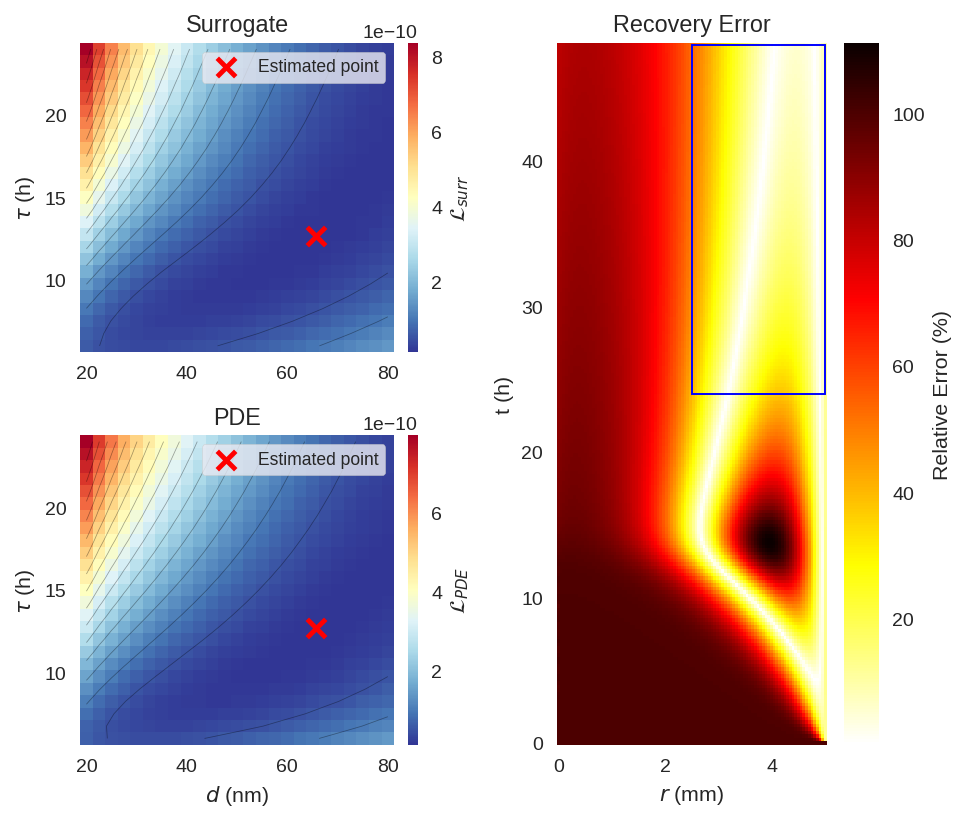

In [24]:
shape = [["C", "E"], ["D", "E"]]
fig, axd = plt.subplot_mosaic(shape, figsize= (7, 6))

plot_surrogate_landscape_grid(
    [L_surr],
    [L_pde],
    d_vals,
    tau_vals,
    [const_res.x],
    fig=fig,
    axes = np.array([axd["C"], axd["D"]])
)
axd["C"].set_title("Surrogate")

rel = np.abs(retrieved_data["CI"] - data_const["CI"]) * 100 / data_const["CI"]
rel.astype(np.int32)

r_vals = retrieved_data["r"] * 1000
t_vals = retrieved_data["t_out"] / 3600

t_idx_1 = 50
t_val_1 = retrieved_data["t_out"][t_idx_1] / 3600
'''
axd["A"].semilogy(r_vals, retrieved_data["CI"][t_idx_1], linestyle="--", color= "orange", label="Retrieved")
axd["A"].semilogy(r_vals, data_const["CI"][t_idx_1], color= "blue", label= "Target")
axd["A"].set_title(f"Profile Comparison at t={t_val_1:.0f}h")
axd["A"].set_ylabel(r"$C_I$ (mol)")
axd["A"].legend()

t_idx_2 = 100
t_val_2 = retrieved_data["t_out"][t_idx_2] / 3600
axd["B"].semilogy(r_vals, retrieved_data["CI"][t_idx_2], linestyle="--", color= "orange", label= "Retrieved")
axd["B"].semilogy(r_vals, data_const["CI"][t_idx_2], color= "blue", label= "Target")
axd["B"].set_title(f"Profile Comparison at t={t_val_2:.0f}h")
axd["B"].set_ylabel(r"$C_I$ (mol)")
axd["B"].legend()
axd["B"].set_xlabel(r"$r$ (mm)")
'''
err_rect = patches.Rectangle((2.5, 24), 2.5, 24, linewidth=1, edgecolor='b', facecolor="none")

err = axd["E"].pcolormesh(r_vals, t_vals, rel, cmap="hot_r")
axd["E"].add_patch(err_rect)
axd["E"].set_xlabel(r"$r$ (mm)")
axd["E"].set_ylabel(r"t (h)")
axd["E"].set_title("Recovery Error")
cbar_err = fig.colorbar(err)
cbar_err.set_label("Relative Error (%)")
fig._suptitle.remove()
fig.tight_layout()

In [ ]:
# Loss landscapes for maximizing fkc
L_surr_fkc = inv.loss_surface(data_const, d_vals, tau_vals, "fkc")
L_pde_fkc = inv.pde_misfit_surface(data_const, d_vals, tau_vals, "fkc")

100%|██████████| 25/25 [07:43<00:00, 18.55s/it]


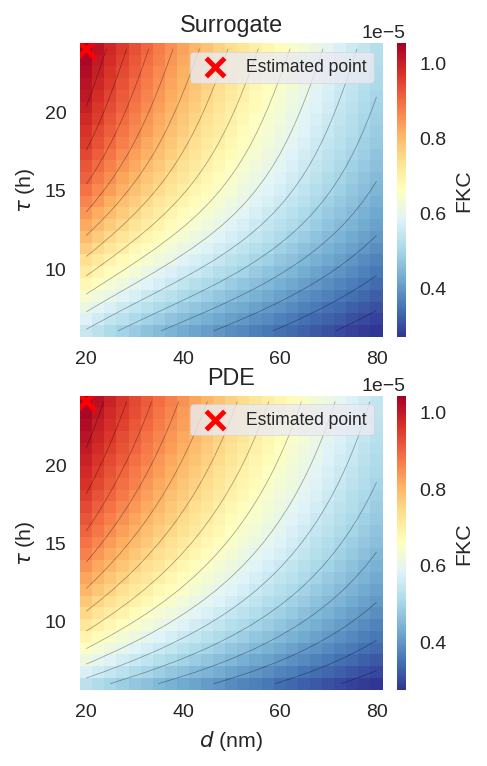

In [32]:
fkc_res = inv.invert(data_const, "fkc")
fig, ax = plt.subplots(2, 1, figsize= (3, 6))
plot_surrogate_landscape_grid(
    [L_surr_fkc],
    [L_pde_fkc],
    d_vals,
    tau_vals,
    [fkc_res.x],
    fig = fig, 
    axes = ax
)
fig._suptitle.remove()
ax[0].set_title("Surrogate")
ax[1].set_title("PDE")
im = ax[0].collections[0]
cbar = im.colorbar
cbar.set_label("FKC")
im = ax[1].collections[0]
cbar = im.colorbar
cbar.set_label("FKC")
plt.show()

In [11]:
# Loss landscapes for maximizing fkc with maximal dosage
L_surr_fkc = inv.loss_surface(data_const, d_vals, tau_vals, "clearance")
L_pde_fkc = inv.pde_misfit_surface(data_const, d_vals, tau_vals, "clearance")

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [07:49<00:00, 18.78s/it]


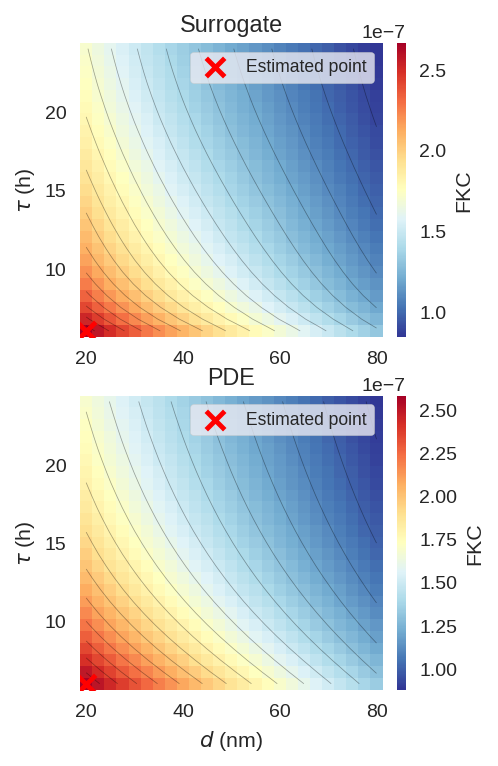

In [ ]:
fkc_res = inv.invert(data_const, "clearance")
fig, ax = plt.subplots(2, 1, figsize= (3, 6))
plot_surrogate_landscape_grid(
    [L_surr_fkc],
    [L_pde_fkc],
    d_vals,
    tau_vals,
    [fkc_res.x],
    fig = fig, 
    axes = ax
)
fig._suptitle.remove()
ax[0].set_title("Surrogate")
ax[1].set_title("PDE")
im = ax[0].collections[0]
cbar = im.colorbar
cbar.set_label("Clearance")
im = ax[1].collections[0]
cbar = im.colorbar
cbar.set_label("Clearance")
plt.show()

In [45]:
train_hist = np.load("/u/mgalexan/NPSurr/data/train_hist.np.npy")
val_hist = np.load("/u/mgalexan/NPSurr/data/val_hist.np.npy")

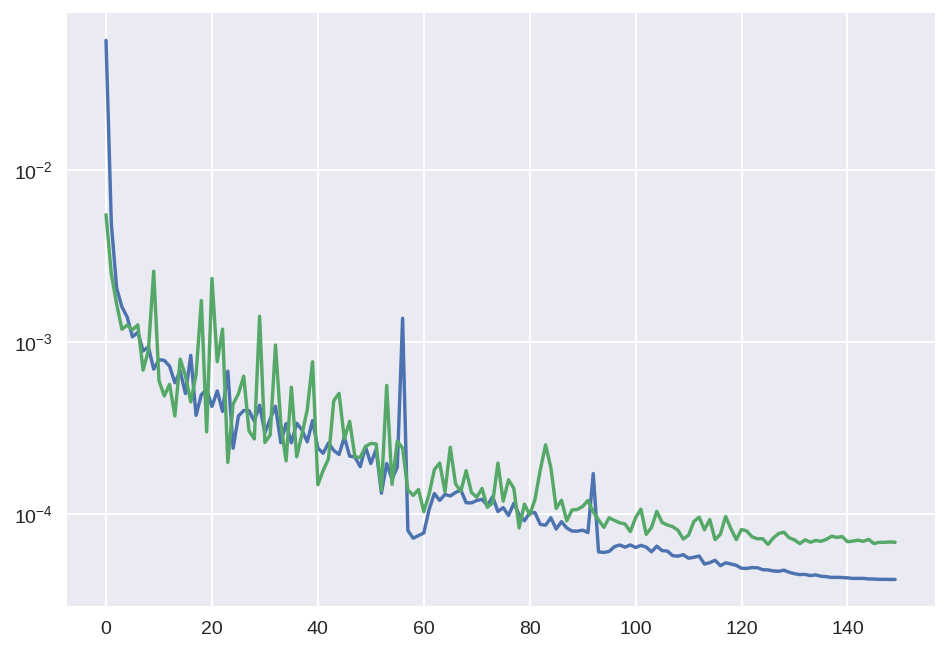

In [46]:
plt.plot(train_hist)
plt.plot(val_hist)
plt.yscale("log")